# Algoritmo Genético Simple — Ejemplo resuelto

## Función a maximizar

$f(x, y) = 21.5 + x \cdot \sin(4 \pi x) + y \cdot \sin(20 \pi y)$

# Paso a paso de un algoritmo genético básico

## 1. Definir los valores de los parámetros

**Definición de parámetros**

| Parámetro | Descripción breve | Descripción |
|----------|------------------|------------|
| Nind = 100 | Número de individuos en la población | Tamaño de la población, es decir, el número total de individuos (posibles soluciones). |
| Lind = 20 | Longitud de los individuos | Longitud de los individuos, determinada por el número de variables y la precisión (número de bits usados para representar cada variable). |
| Pc = 0.9 | Probabilidad de cruzamiento | Probabilidad de que ocurra el cruce entre individuos. Generalmente se define entre 60% y 100%, ya que el cruzamiento ocurre con alta frecuencia. |
| Pm = 0.01 | Probabilidad de mutación | Probabilidad de que ocurra una mutación. Es baja, ya que las mutaciones en la naturaleza son poco frecuentes (hasta ~10% de la longitud del individuo). |
| Maxgen = 1000 | Máximo número de generaciones | Número máximo de iteraciones del algoritmo. Define cuántas veces evoluciona la población. |
| Nvar = 2 | Número de variables | Cantidad de variables independientes del problema. |
| Rango = [[-3, 4.1], [12.1, 5.8]] | Rango de las variables del problema | Define los intervalos en los que pueden tomar valores las variables de decisión del problema. |

In [21]:
# Valores de las variables
import numpy as np
import matplotlib.pyplot as plt

Nind = 100
Lind = 33
Pc = 0.9
Pm = 0.01
Maxgen = 1000
Nvar = 2
rango = np.array([[-3, 12.1], [4.1, 5.8]])

## A continuación, se desarrollan las funciones del algoritmo genético:


### `creapob`

In [22]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

### `decodifica`

In [3]:
def decodifica(genotipo, rango):
    Nvar = rango.shape[0]
    Nind, Lind = genotipo.shape

    bits_por_var = np.full(Nvar, Lind // Nvar, dtype=int)
    bits_por_var[: Lind % Nvar] += 1

    fenotipo = np.zeros((Nind, Nvar))
    inicio = 0

    for j, Lvar in enumerate(bits_por_var):
        fin = inicio + Lvar
        subcadena = genotipo[:, inicio:fin]
        potencias = 2 ** np.arange(Lvar - 1, -1, -1)
        decimal = subcadena @ potencias
        li, ls = rango[j]
        fenotipo[:, j] = li + ((ls - li) / (2 ** Lvar - 1)) * decimal
        inicio = fin

    return fenotipo


La codificación de las variables responde a las siguientes fórmulas.

Esto significa que de la cadena binaria a las variables de decisión en el dominio del problema, se procede a evaluar la función para obtener su valor objetivo.


### `objfun`

In [4]:
def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        objv[i, 0] = 21.5 + fenotipo[i, 0] * np.sin(4 * np.pi * fenotipo[i, 0]) + fenotipo[i, 1] * np.sin(20 * np.pi * fenotipo[i, 1])

    return objv

### `rankeo`

In [23]:
def rankeo(objv, direccion):
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        posori = np.argsort(objv[:, 0])
    else:
        posori = np.argsort(-objv[:, 0])

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    aptitud[posori, 0] = apt

    return aptitud

### `ruleta`

In [6]:
def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]

    nuevo_gen = genotipo[idx.flatten(), :]

    return nuevo_gen

### `xunpunto`

In [ ]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    return aux_gen

### `muta`

In [ ]:
def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    mascara = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, mascara).astype(int)

    return nuevo_gen

## 2. Crear la población inicial

Se crean los nodos (individuos) de la población de forma aleatoria, que son el espacio de soluciones potenciales para resolver la función objetivo. Cada nodo debe decodificarse a binario.


In [ ]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)

## 3. Obteniendo el valor óptimo

El valor óptimo corresponde al “mejor valor” encontrado en la función objetivo, así como las variables que permitieron encontrarlo.


In [ ]:
Mejor = np.full((Maxgen, 1), np.nan)  # Referencia al mejor valor óptimo encontrado de la función objetivo
Mejor_cromosoma = np.zeros((Maxgen, Lind), dtype=int)  # Mejor cromosoma encontrado por cada generación
objv = objfun(fenotipo)  # evaluación de la función

idx0 = np.argmax(objv)
Mejor[0] = objv[idx0]
Mejor_cromosoma[0, :] = genotipo[idx0, :]

## 4. Ciclo Evolutivo

Una vez creada y evaluada la población inicial, se procede al ciclo evolutivo.


In [ ]:
generaciones = 1

while generaciones < Maxgen:  # Número de generaciones predefinidas
    aptitud = rankeo(objv, 1)  # cada generación se establece el fitness para cada solución encontrada
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)

    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)

    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv = nuevo_objv

    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

Agregar el código necesario para almacenar las mejores soluciones de cada generación e imprimir el mejor valor de todas las generaciones.


In [ ]:
idx_mejor = np.nanargmax(Mejor[:, 0])
mejor_valor = float(Mejor[idx_mejor, 0])
mejor_cromosoma = Mejor_cromosoma[idx_mejor, :].astype(int)
mejor_fenotipo = decodifica(mejor_cromosoma.reshape(1, -1), rango)[0]

print(f'Mejor generación: {idx_mejor}')
print(f'Mejor valor encontrado: {mejor_valor:.6f}')
print(f'Mejor cromosoma: {mejor_cromosoma}')
print(f'Mejor solución (x, y): {mejor_fenotipo}')

Mejor generación: 421
Mejor valor encontrado: 38.850291
Mejor cromosoma: [1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 0 1]
Mejor solución (x, y): [11.6255869   5.72503243]


## Resultado esperado

Implemente el código necesario para su graficación.

Replique el código anterior, agregando las librerías que hagan falta.

Compare los resultados con la programación estructurada (sin AG) que a continuación se muestra:


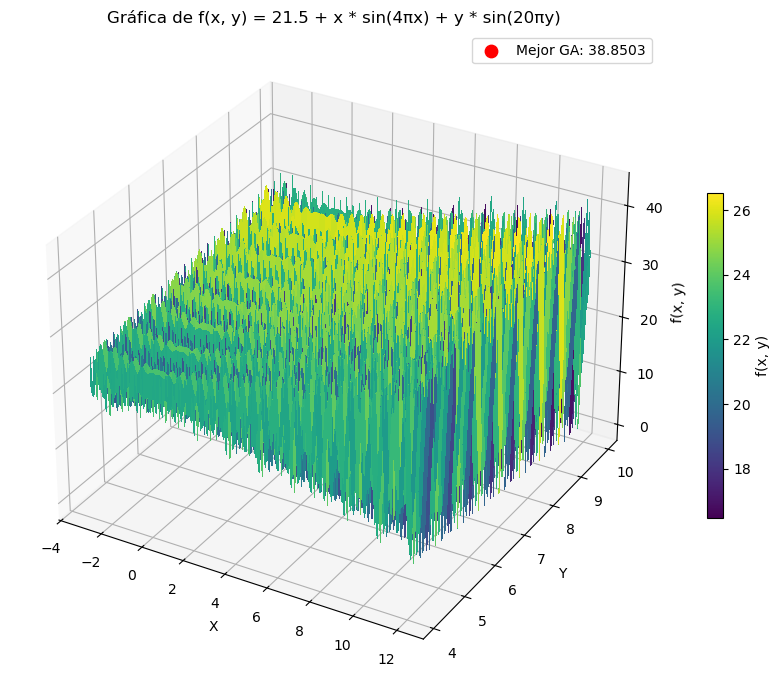

In [24]:
import matplotlib.pyplot as plt

x = np.linspace(rango[0, 0], rango[0, 1], 200)
y = np.linspace(rango[1, 0], rango[1, 0] + rango[1, 1], 200)
X, Y = np.meshgrid(x, y)

feno_malla = np.column_stack([X.ravel(), Y.ravel()])
Z = objfun(feno_malla).reshape(X.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, label='f(x, y)')

# Usar objv y genotipo del estado final del GA
idx_mejor = np.argmax(objv)
mejor_feno = decodifica(genotipo[idx_mejor, :].reshape(1, -1), rango)
z_mejor = objfun(mejor_feno).item()

ax.scatter(mejor_feno[0, 0], mejor_feno[0, 1], z_mejor,
           color='red', s=80, zorder=5, label=f'Mejor GA: {z_mejor:.4f}')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) = 21.5 + x * sin(4πx) + y * sin(20πy)')
ax.legend()
plt.tight_layout()
plt.show()

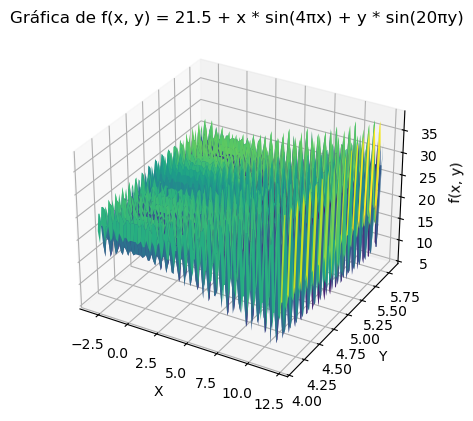

In [ ]:
# Definir la función
def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

# Generar datos para x y y
x = np.linspace(rango[0, 0], rango[0, 1], 100)
y = np.linspace(rango[1, 0], rango[1, 1], 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Crear la gráfica en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

# Etiquetas y título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) = 21.5 + x * sin(4πx) + y * sin(20πy)')

# Mostrar la gráfica
plt.show()